In [1]:
import pandas as pd
import os

In [2]:
#loading the files
base_df = pd.read_csv('../data/data_final_with_aadt_and_vulnerability.csv')
#select only columns needed
base_subset = base_df[['id', 'avg_truck_AADT','lat', 'lon']]

scenario_results = {}
all_dfs = []
scenario_stats = []

#loop through 12 scenario files
for i in range(12):
    file_path = f'../experiment/final_delays_scenario{i}.csv'
    raw_scenario_df = pd.read_csv(file_path)

    #melt the data from wide to long format:
    #each column (seed) becomes a row
    melted_df = raw_scenario_df.melt(id_vars=['BridgeID'], var_name='Seed', value_name='Delay')

    #drops rows where Delay is missing
    melted_df = melted_df.dropna(subset=['Delay'])

    #calculate the number of unique bridges affected per seed
    bridges_per_seed = melted_df.groupby('Seed')['BridgeID'].nunique()

    #compute the average number of broken bridges in this scenario
    avg_broken_this_scenario = bridges_per_seed.mean()
    scenario_stats.append(avg_broken_this_scenario)

    #compute the averge delay per bridge across all seeds
    scenario_avg = melted_df.groupby('BridgeID')['Delay'].mean().reset_index()

    #merge with base data (AADT and location info)
    merged_df = pd.merge(
        scenario_avg,
        base_subset,
        left_on='BridgeID',
        right_on='id'
    ).copy()

    #rename columns and drop duplicate ID column
    merged_df = merged_df.rename(columns={'Delay': 'Total_Delay'}).drop(columns=['BridgeID'])

    #compute raw impact: delay multiplied by truck traffic
    merged_df['impact_raw'] = merged_df['Total_Delay'] * merged_df['avg_truck_AADT']
    merged_df['scenario_id'] = i

    all_dfs.append(merged_df)

#combine all scenario data to calculate global min and max
combined_data = pd.concat(all_dfs)
global_min = combined_data['impact_raw'].min()
global_max = combined_data['impact_raw'].max()

#scale impact values between 0 and 1 (min-max scaling)
for i in range(len(all_dfs)):
    all_dfs[i].loc[:, 'impact_scaled'] = (all_dfs[i]['impact_raw'] - global_min) / (global_max - global_min)

    scenario_results[f'scenario_{i}'] = all_dfs[i]

    #create seperate variables for each scenario (df_0, df_1, etc.)
    globals()[f'df_{i}'] = all_dfs[i]


In [3]:
#total amount of bridges
count_bridges = len(base_df[base_df['model_type'] == 'bridge'])

print(f"Amount bridges: {count_bridges}")

Amount bridges: 1434


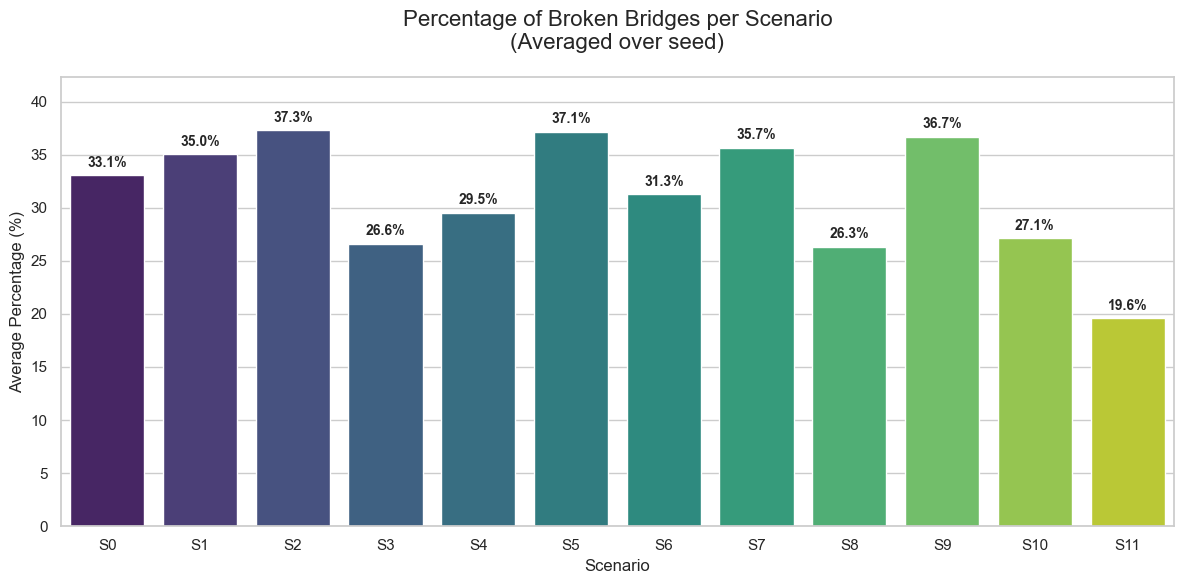

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

#calculate percentages based on the average broken bridges per seed (from scenario_stats)
#'count_bridges' is the total number of bridges in base_df
percentages = [(avg_count / count_bridges) * 100 for avg_count in scenario_stats]
labels = [f"S{i}" for i in range(len(scenario_stats))]

plot_df = pd.DataFrame({
    'Scenario': labels,
    'Percentage': percentages
})

sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

ax = sns.barplot(x='Scenario', y='Percentage', data=plot_df, palette='viridis', hue='Scenario', legend=False)


plt.title('Percentage of Broken Bridges per Scenario\n(Averaged over seed)', fontsize=16, pad=20)
plt.ylabel('Average Percentage (%)', fontsize=12)
plt.xlabel('Scenario', fontsize=12)

plt.ylim(0, max(percentages) + 5)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold')

plt.tight_layout()

plt.savefig('../img/average_broken_bridges_per_seed.png', dpi=300, bbox_inches='tight')

plt.show()

In [7]:
combined_df = pd.concat(all_dfs)

avg_impact_per_bridge = combined_df.groupby('id').agg({
    'impact_scaled': 'mean',
    'impact_raw': 'mean',
    'avg_truck_AADT': 'first',
    'lat': 'first',
    'lon': 'first',
    'scenario_id': lambda x: list(x)
}).rename(columns={'scenario_id': 'scenarios_found'})

#compute average impact per bridge across all scenarios
avg_impact_per_bridge['occurrence_count'] = avg_impact_per_bridge['scenarios_found'].apply(len)

#count how many scenarios each bridge appears in
avg_impact_per_bridge = avg_impact_per_bridge.sort_values(by='impact_scaled', ascending=False)

avg_impact_per_bridge[['impact_scaled', 'occurrence_count', 'scenarios_found']].head(20)

,impact_scaled,occurrence_count,scenarios_found
id,,,
100083,0.879217,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100047,0.829622,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100051,0.783681,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
101484,0.647530,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100031,0.442117,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100075,0.422411,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100049,0.401661,11,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]"
100043,0.397597,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"
100059,0.371042,12,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]"


In [13]:
avg_impact_per_bridge.head(20)

,impact_scaled,impact_raw,avg_truck_AADT,lat,lon,scenarios_found,occurrence_count
id,,,,,,,
100083,0.879217,5.692121e+08,2261.666667,23.530384,90.702440,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
100047,0.829622,5.371214e+08,2261.666667,23.617641,90.609551,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
100051,0.783681,5.073944e+08,2082.666667,23.602760,90.615532,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
101484,0.647530,4.192964e+08,1730.000000,23.871651,90.506546,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11
100031,0.442117,2.863820e+08,2597.666667,23.654426,90.576730,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
100075,0.422411,2.736308e+08,2261.666667,23.542685,90.674829,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
100049,0.401661,2.602040e+08,2261.666667,23.613587,90.610903,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11
100043,0.397597,2.575745e+08,2261.666667,23.628467,90.602302,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
100059,0.371042,2.403920e+08,2082.666667,23.577980,90.641919,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12


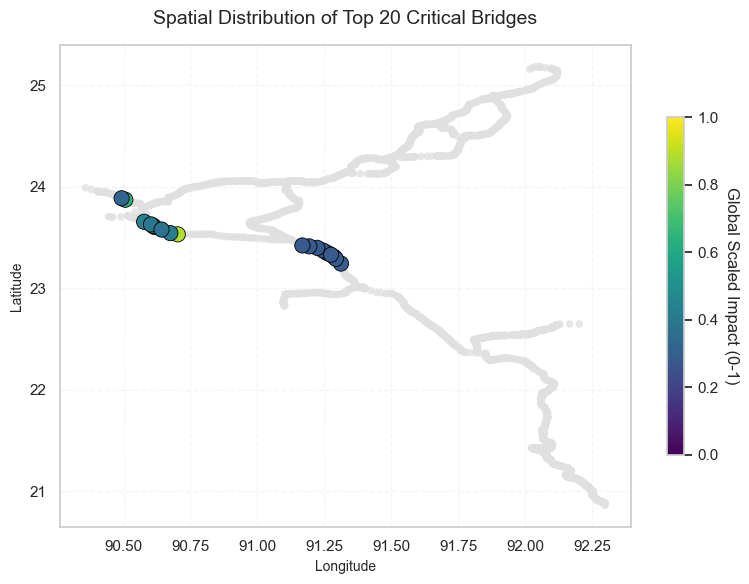

In [8]:
top_20_df = avg_impact_per_bridge.head(20).copy().reset_index()

fig, ax = plt.subplots(figsize=(8, 6))

#layer1
ax.scatter(base_df['lon'], base_df['lat'],
           color='#e0e0e0',
           s=30,
           alpha=0.8,
           edgecolor='none',
           zorder=1)

#layer2 most critical bridges
sc = ax.scatter(top_20_df['lon'], top_20_df['lat'],
                c=top_20_df['impact_scaled'],
                cmap='viridis',
                s=120,
                alpha=1.0,
                edgecolor='black',
                linewidth=0.6,
                zorder=2)

ax.set_title("Spatial Distribution of Top 20 Critical Bridges", fontsize=14, pad=15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.grid(True, linestyle='--', alpha=0.2)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Global Scaled Impact (0-1)', rotation=270, labelpad=15)
sc.set_clim(0, 1)

plt.tight_layout()

plt.savefig('../img/broken_bridges_map.png', dpi=300, bbox_inches='tight')

plt.show()

In [9]:
top_20_df.head(20)

,id,impact_scaled,impact_raw,avg_truck_AADT,lat,lon,scenarios_found,occurrence_count
0,100083,0.879217,5.692121e+08,2261.666667,23.530384,90.702440,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
1,100047,0.829622,5.371214e+08,2261.666667,23.617641,90.609551,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
2,100051,0.783681,5.073944e+08,2082.666667,23.602760,90.615532,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
3,101484,0.647530,4.192964e+08,1730.000000,23.871651,90.506546,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11
4,100031,0.442117,2.863820e+08,2597.666667,23.654426,90.576730,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
5,100075,0.422411,2.736308e+08,2261.666667,23.542685,90.674829,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
6,100049,0.401661,2.602040e+08,2261.666667,23.613587,90.610903,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11
7,100043,0.397597,2.575745e+08,2261.666667,23.628467,90.602302,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
8,100059,0.371042,2.403920e+08,2082.666667,23.577980,90.641919,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12
9,101490,0.322376,2.089019e+08,1730.000000,23.885891,90.492776,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12


In [10]:
base_df.head()

,fid,field_1,road,id,model_type,condition,name,lat,lon,length,avg_truck_AADT,WMO_WIND_I,distance,elevation
0,1,0,N1,100001,sourcesink,NaN,SoSi1,23.706028,90.443333,0.00,2463.666667,235,2486.289017,10
1,2,1,N1,100002,link,NaN,NaN,23.702383,90.451097,1794.35,2626.666667,235,2686.190118,10
2,3,2,N1,100003,bridge,A,NaN,23.698739,90.458861,11.30,2789.666667,235,2891.272003,8
3,4,3,N1,100004,link,NaN,NaN,23.702411,90.490194,6947.35,2134.666667,235,1865.948830,7
4,5,4,N1,100005,intersection,NaN,NaN,23.706083,90.521527,20.00,1479.666667,235,403.471772,10


In [11]:
extra_cols = ['id', 'length', 'condition', 'WMO_WIND_I', 'distance', 'elevation']

top_20_details = pd.merge(
    top_20_df,
    base_df[extra_cols],
    on='id',
    how='left'
)

top_20_details.head(20)

,id,impact_scaled,impact_raw,avg_truck_AADT,lat,lon,scenarios_found,occurrence_count,length,condition,WMO_WIND_I,distance,elevation
0,100083,0.879217,5.692121e+08,2261.666667,23.530384,90.702440,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,1408.80,A,205,63.578205,5
1,100047,0.829622,5.371214e+08,2261.666667,23.617641,90.609551,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,224.80,A,205,821.953805,5
2,100051,0.783681,5.073944e+08,2082.666667,23.602760,90.615532,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,924.85,A,205,0.000000,7
3,101484,0.647530,4.192964e+08,1730.000000,23.871651,90.506546,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11,209.00,A,235,3642.739819,14
4,100031,0.442117,2.863820e+08,2597.666667,23.654426,90.576730,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,159.52,C,205,4347.927580,9
5,100075,0.422411,2.736308e+08,2261.666667,23.542685,90.674829,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,72.49,A,205,1017.086128,4
6,100049,0.401661,2.602040e+08,2261.666667,23.613587,90.610903,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]",11,119.32,A,205,578.433025,6
7,100043,0.397597,2.575745e+08,2261.666667,23.628467,90.602302,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,86.92,A,205,659.470100,6
8,100059,0.371042,2.403920e+08,2082.666667,23.577980,90.641919,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,172.10,A,205,346.961483,7
9,101490,0.322376,2.089019e+08,1730.000000,23.885891,90.492776,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]",12,174.75,A,235,3660.903796,8


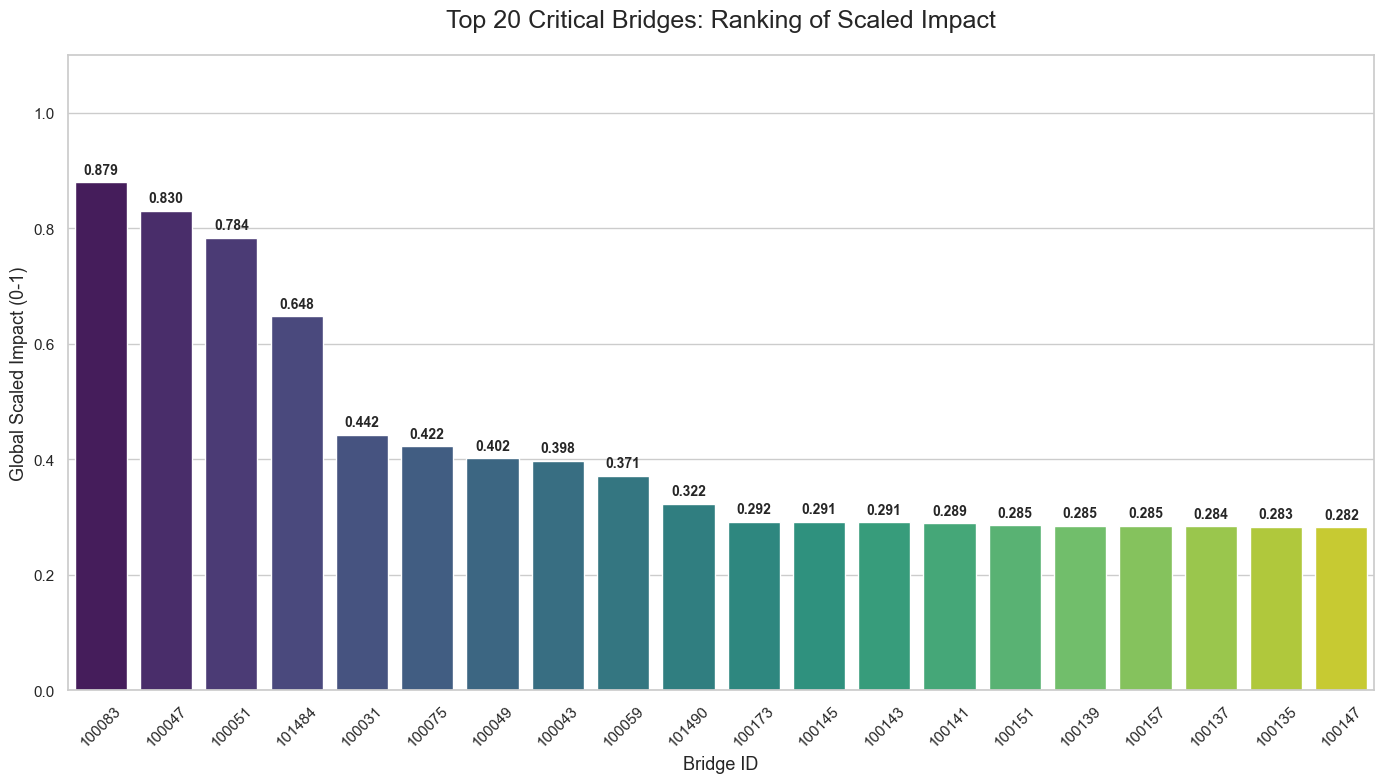

In [17]:
plot_top_20 = top_20_df.sort_values('impact_scaled', ascending=False)

plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")

ax = sns.barplot(
    x=plot_top_20['id'].astype(str),
    y='impact_scaled',
    data=plot_top_20,
    palette='viridis',
    hue=plot_top_20['id'].astype(str),
    legend=False
)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center',
                xytext=(0, 9),
                textcoords='offset points',
                fontsize=10,
                fontweight='bold',
                rotation=0)

plt.title('Top 20 Critical Bridges: Ranking of Scaled Impact', fontsize=18, pad=20)
plt.ylabel('Global Scaled Impact (0-1)', fontsize=13)
plt.xlabel('Bridge ID', fontsize=13)

plt.xticks(rotation=45)

plt.ylim(0, 1.1)

plt.tight_layout()

plt.savefig('../img/top_20_impact_vertical_ranking.png', dpi=300, bbox_inches='tight')

plt.show()

In [27]:
#list with 4 most critical and vulnerable id's
top_4_ids = [100083, 100047, 100051, 101484]

top_4_details = top_20_details[top_20_details['id'].isin(top_4_ids)].copy()

top_4_details = top_4_details.sort_values('impact_scaled', ascending=False)

top_4_details[['id', 'impact_scaled', 'length', 'condition', 'avg_truck_AADT', 'distance', 'elevation', 'WMO_WIND_I', 'lat', 'lon']]

,id,impact_scaled,length,condition,avg_truck_AADT,distance,elevation,WMO_WIND_I,lat,lon
0,100083,0.879217,1408.80,A,2261.666667,63.578205,5,205,23.530384,90.702440
1,100047,0.829622,224.80,A,2261.666667,821.953805,5,205,23.617641,90.609551
2,100051,0.783681,924.85,A,2082.666667,0.000000,7,205,23.602760,90.615532
3,101484,0.647530,209.00,A,1730.000000,3642.739819,14,235,23.871651,90.506546


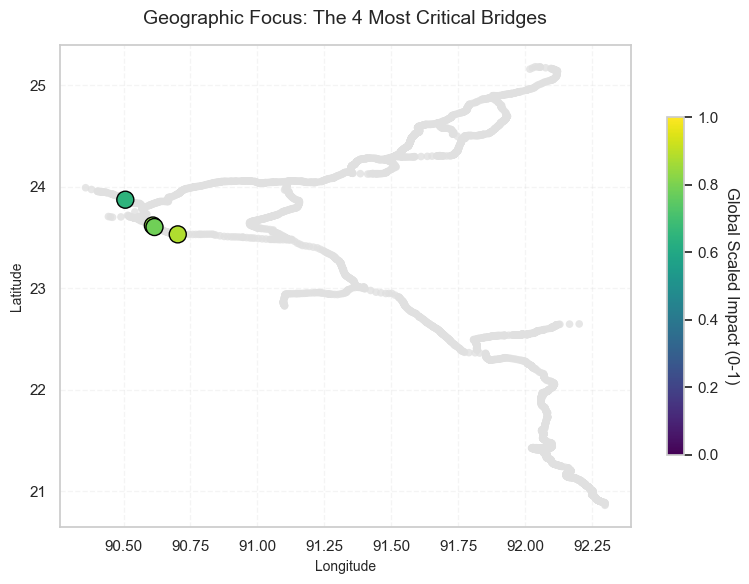

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(base_df['lon'], base_df['lat'],
           color='#e0e0e0',
           s=30,
           alpha=0.8,
           edgecolor='none',
           zorder=1)

sc = ax.scatter(top_4_details['lon'], top_4_details['lat'],
                c=top_4_details['impact_scaled'],
                cmap='viridis',
                s=150,
                alpha=1.0,
                edgecolor='black',
                linewidth=1.0,
                zorder=2)

ax.set_title("Geographic Focus: The 4 Most Critical Bridges", fontsize=14, pad=15)
ax.set_xlabel("Longitude", fontsize=10)
ax.set_ylabel("Latitude", fontsize=10)

ax.grid(True, linestyle='--', alpha=0.2)

cbar = plt.colorbar(sc, ax=ax, shrink=0.7)
cbar.set_label('Global Scaled Impact (0-1)', rotation=270, labelpad=15)
sc.set_clim(0, 1)

plt.tight_layout()

plt.savefig('../img/top_4_critical_bridges_map.png', dpi=300, bbox_inches='tight')

plt.show()